<a href="https://colab.research.google.com/github/JheanmarcoOscanoa/Laboratorio-04/blob/main/Laboratorio_N%C2%B004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTEGRACIÓN, LIMPIEZA Y TRANSFORMACIÓN DE DATOS  
## Laboratorio N°04 – Minería de Datos

**Nombre:** Jheanmarco Deivis OSCANOA VARGAS

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np

### Objetivo del laboratorio:
Aplicar técnicas de preprocesamiento de datos usando Python para preparar un conjunto real del UCI Machine Learning Repository, a través de imputación, detección de outliers univariados y multivariados, y transformación de variables predictoras.

### a.1 Carga, imputación y transformación de variables
- Se utilizó el dataset **Breast Cancer Wisconsin (Original)**, cargado desde el [UCI Repository](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original)).
- Se asignaron nombres de columnas según la documentación oficial.
- La variable `Bare_Nuclei` presentaba valores faltantes (`'?'`), los cuales fueron imputados mediante la **mediana**.
- La variable `Class` fue recodificada de 2 (benigno) y 4 (maligno) a **0** y **1**, respectivamente.


In [2]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
df = pd.read_csv(url, header=None)
df

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


### a.2 Asignamos nombres de columnas basado en la documentación oficial del dataset

In [3]:

df.columns = [
    'Sample_code_number',         # ID único del paciente
    'Clump_Thickness',            # Grosor del agrupamiento celular
    'Uniformity_Cell_Size',       # Uniformidad del tamaño celular
    'Uniformity_Cell_Shape',      # Uniformidad de la forma celular
    'Marginal_Adhesion',          # Adhesión marginal
    'Single_Epithelial_Cell_Size',# Tamaño de células epiteliales individuales
    'Bare_Nuclei',                # Núcleos desnudos (puede tener valores faltantes)
    'Bland_Chromatin',            # Cromatina tenue
    'Normal_Nucleoli',            # Nucléolos normales
    'Mitoses',                    # Número de mitosis
    'Class'                       # Variable objetivo: 2 (benigno), 4 (maligno)
]

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample_code_number           699 non-null    int64 
 1   Clump_Thickness              699 non-null    int64 
 2   Uniformity_Cell_Size         699 non-null    int64 
 3   Uniformity_Cell_Shape        699 non-null    int64 
 4   Marginal_Adhesion            699 non-null    int64 
 5   Single_Epithelial_Cell_Size  699 non-null    int64 
 6   Bare_Nuclei                  699 non-null    object
 7   Bland_Chromatin              699 non-null    int64 
 8   Normal_Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [5]:
df["Bare_Nuclei"].value_counts()

,count
Bare_Nuclei,
1,402
10,132
2,30
5,30
3,28
8,21
4,19
?,16
9,9


In [6]:
df["Class"].value_counts()

,count
Class,
2,458
4,241


### a.3 Función para imputar valores faltantes con la mediana

In [7]:
# Función para imputar valores faltantes con la mediana
def imputar_mediana(col):
    col = col.replace('?', np.nan)
    col = pd.to_numeric(col)
    return col.fillna(col.median())

# Aplicar la función a la columna 'Bare_Nuclei'
df['Bare_Nuclei'] = imputar_mediana(df['Bare_Nuclei'])

In [8]:
# verificamos
df["Bare_Nuclei"].value_counts()

,count
Bare_Nuclei,
1.0,418
10.0,132
2.0,30
5.0,30
3.0,28
8.0,21
4.0,19
9.0,9
7.0,8


###  a.4 Transformación de la columna Class usando lambda

In [9]:
# Usamos lambda para mapear los valores 2 → 0 y 4 → 1 en la columna 'Class'
df['Class'] = df['Class'].apply(lambda x: 0 if x == 2 else 1)

In [10]:
df['Class'].unique()

array([0, 1])

## b. Realice una detección de valores atípicos univariados por medio del método del rango intercuartílico con 3 de longitud a la derecha y 3 a la izquierda, y elimínelos. Además, realice una detección de valores atípicos multivariados por medio de las distancias de Mahalanobis y elimine aquellos valores que superen el valor de 30.


### b.1 Detección de valores atípicos univariados usando el método del rango intercuartílico (IQR)

In [11]:
# Seleccionar solo columnas numéricas predictoras (excluyendo ID y target)
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
columnas_predictoras = columnas_numericas.drop(['Sample_code_number', 'Class'])

# Eliminar valores atípicos univariados por IQR con k=3
for col in columnas_predictoras:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 3 * IQR
    limite_superior = Q3 + 3 * IQR
    df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]

# Mostrar forma final del dataframe tras limpieza
print("Dimensión del dataset limpio:", df.shape)



Dimensión del dataset limpio: (579, 11)


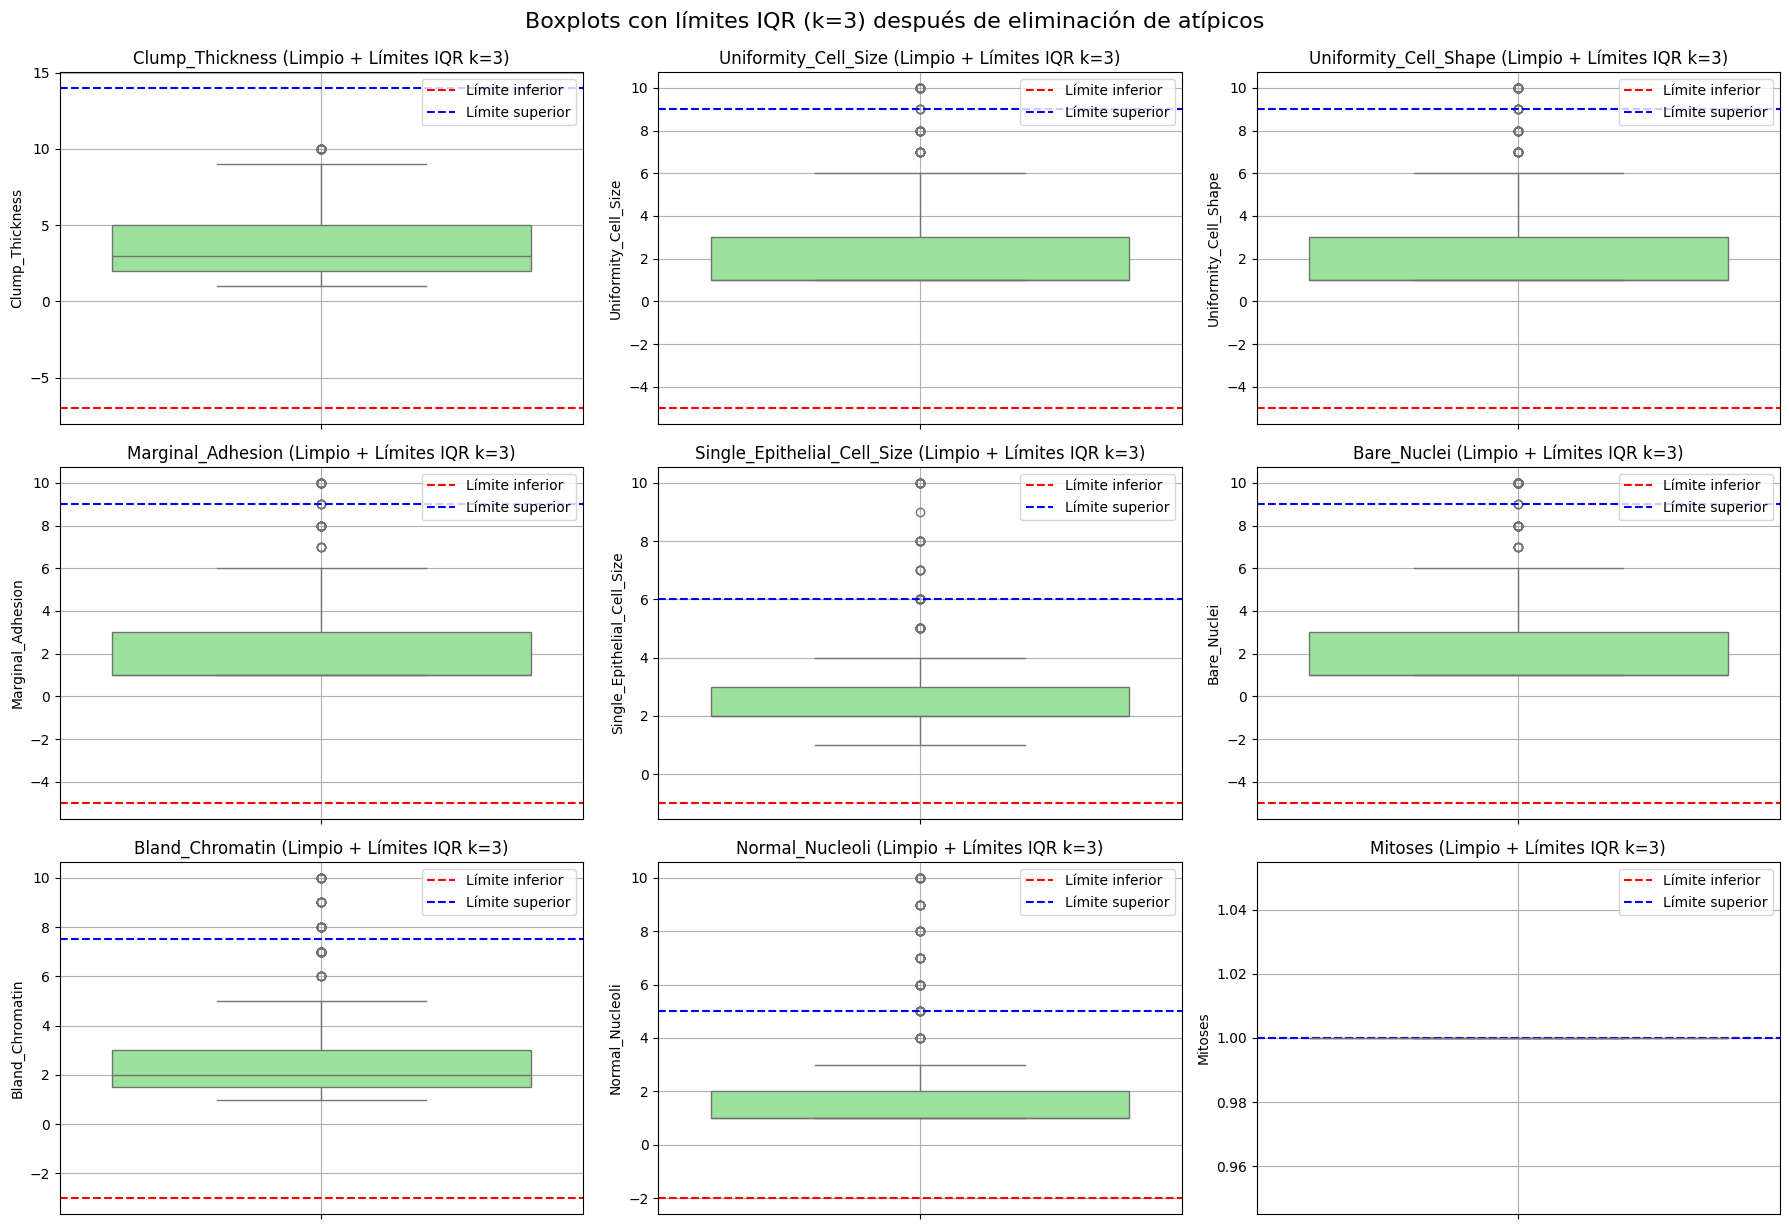

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar solo columnas numéricas predictoras
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
columnas_predictoras = columnas_numericas.drop(['Sample_code_number', 'Class'])

# Subplots para cada variable
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(columnas_predictoras):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].axhline(lower, color='red', linestyle='--', label='Límite inferior')
    axes[i].axhline(upper, color='blue', linestyle='--', label='Límite superior')
    axes[i].set_title(f'{col} (Limpio + Límites IQR k=3)')
    axes[i].legend()
    axes[i].grid(True)

# Ajustar presentación
plt.tight_layout()
plt.suptitle('Boxplots con límites IQR (k=3) después de eliminación de atípicos', fontsize=16, y=1.02)
plt.show()


In [13]:
df

,Sample_code_number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
692,714039,3,1,1,1,2,1.0,1,1,1,0
694,776715,3,1,1,1,3,2.0,1,1,1,0
695,841769,2,1,1,1,2,1.0,1,1,1,0
697,897471,4,8,6,4,3,4.0,10,6,1,1


### b.2 Detección de valores atípicos multivariados con distancia de Mahalanobis

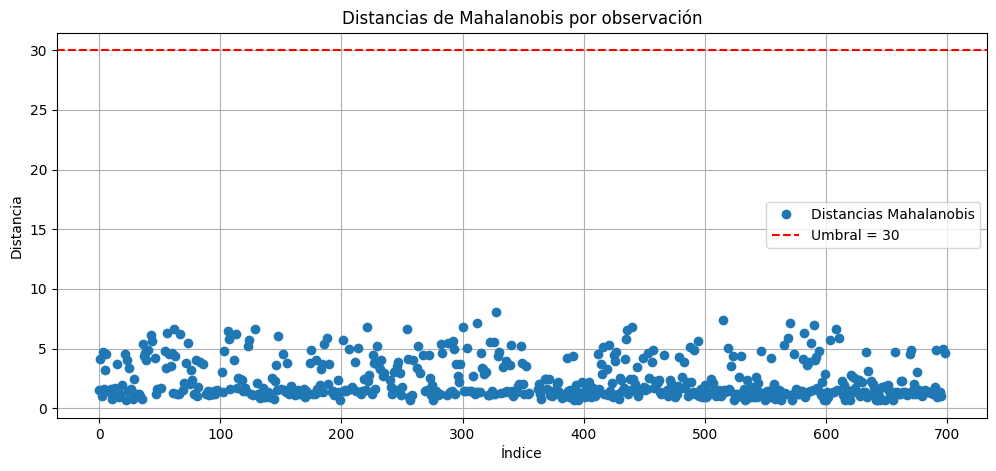

Dimensiones finales tras eliminar valores atípicos multivariados: (579, 11)


In [15]:
from scipy.spatial.distance import mahalanobis
import numpy as np
import matplotlib.pyplot as plt

# Selección de variables predictoras
columnas_predictoras = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Sample_code_number', 'Class']).columns
X = df[columnas_predictoras]

# Media y pseudoinversa de la matriz de covarianza
media = X.mean().values
cov_matrix = np.cov(X.T)
cov_inv = np.linalg.pinv(cov_matrix)  # Usamos pinv en lugar de inv

# Cálculo de distancia de Mahalanobis
dist_maha = X.apply(lambda fila: mahalanobis(fila.values, media, cov_inv), axis=1)
df['Dist_Mahalanobis'] = dist_maha

# Visualización y eliminación
plt.figure(figsize=(12, 5))
plt.plot(dist_maha, marker='o', linestyle='', label='Distancias Mahalanobis')
plt.axhline(30, color='red', linestyle='--', label='Umbral = 30')
plt.title('Distancias de Mahalanobis por observación')
plt.xlabel('Índice')
plt.ylabel('Distancia')
plt.legend()
plt.grid(True)
plt.show()

# Eliminar valores multivariadamente atípicos
df = df[df['Dist_Mahalanobis'] <= 30]
df = df.drop(columns=['Dist_Mahalanobis'])

print("Dimensiones finales tras eliminar valores atípicos multivariados:", df.shape)


## c. Realice un cálculo de los principales estadísticos descriptivos para las variables predictoras y cree dos conjuntos de datos: uno en donde se aplique la transformación Z-score y otro en donde se aplique la normalización mín-máx, sobre todas las variables predictoras.

### c.1 Realice un cálculo de los principales estadísticos descriptivos para las variables predictoras.

In [16]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Seleccionar solo las variables predictoras numéricas (ya limpias)
columnas_predictoras = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Sample_code_number', 'Class']).columns
X = df[columnas_predictoras]

# 1. Estadísticos descriptivos
estadisticas = X.describe().T  # transpuesta para mejor lectura
print("Estadísticos descriptivos de las variables predictoras:")
display(estadisticas)

Estadísticos descriptivos de las variables predictoras:


,count,mean,std,min,25%,50%,75%,max
Clump_Thickness,579.0,3.851468,2.528463,1.0,2.0,3.0,5.0,10.0
Uniformity_Cell_Size,579.0,2.449050,2.587315,1.0,1.0,1.0,3.0,10.0
Uniformity_Cell_Shape,579.0,2.578584,2.550926,1.0,1.0,1.0,3.0,10.0
Marginal_Adhesion,579.0,2.219344,2.315565,1.0,1.0,1.0,3.0,10.0
Single_Epithelial_Cell_Size,579.0,2.754750,1.807890,1.0,2.0,2.0,3.0,10.0
Bare_Nuclei,579.0,2.718480,3.153268,1.0,1.0,1.0,3.0,10.0
Bland_Chromatin,579.0,3.003454,2.199400,1.0,1.5,2.0,3.0,10.0
Normal_Nucleoli,579.0,2.184801,2.491239,1.0,1.0,1.0,2.0,10.0
Mitoses,579.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


### c.2 Cree dos conjuntos de datos: uno en donde se aplique la transformación Z-score y otro en donde se aplique la normalización mín-máx, sobre todas las variables predictoras.

In [17]:
# C.2.1 Z-score (media 0, desviación estándar 1)
scaler_z = StandardScaler()
X_zscore = pd.DataFrame(scaler_z.fit_transform(X), columns=columnas_predictoras)
print("Primeras filas del conjunto Z-score:")
display(X_zscore.head())

Primeras filas del conjunto Z-score:


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,0.454634,-0.560544,-0.619363,-0.527041,-0.417836,-0.545455,-0.001572,-0.475998,0.0
1,0.454634,0.599962,0.557698,1.201893,2.350209,2.311194,-0.001572,-0.074245,0.0
2,-0.337044,-0.560544,-0.619363,-0.527041,-0.417836,-0.228050,-0.001572,-0.475998,0.0
3,0.850473,2.147303,2.127112,-0.527041,0.135773,0.406761,-0.001572,1.934524,0.0
4,0.058795,-0.560544,-0.619363,0.337426,-0.417836,-0.545455,-0.001572,-0.475998,0.0


In [18]:
# C.2.2 Min-Max (rango [0, 1])
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=columnas_predictoras)
print("Primeras filas del conjunto Min-Max:")
display(X_minmax.head())

Primeras filas del conjunto Min-Max:


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,0.444444,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.000000,0.0
1,0.444444,0.333333,0.333333,0.444444,0.666667,1.000000,0.222222,0.111111,0.0
2,0.222222,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.000000,0.0
3,0.555556,0.777778,0.777778,0.000000,0.222222,0.333333,0.222222,0.666667,0.0
4,0.333333,0.000000,0.000000,0.222222,0.111111,0.000000,0.222222,0.000000,0.0
